In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Title,3810
Review Text,845
Class Name,14
Division Name,14
Department Name,14
Clothing ID,0
Age,0
Rating,0
Recommended IND,0
Positive Feedback Count,0


In [ ]:
df = df.dropna(subset=['Review Text'])

df['Title'] = df['Title'].fillna('')
df['Division Name'] = df['Division Name'].fillna('Unknown')
df['Department Name'] = df['Department Name'].fillna('Unknown')
df['Class Name'] = df['Class Name'].fillna('Unknown')

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,22640.000000,22640.000000,22640.000000,22640.000000,22640.000000
mean,919.327827,43.280654,4.183525,0.818860,2.630698
std,202.270191,12.327181,1.115774,0.385142,5.786265
min,1.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


## Exploratory Data Analysis (EDA)

Tahap EDA dilakukan untuk memahami karakteristik dataset melalui analisis distribusi data, kategori produk, serta pola ulasan pelanggan.

In [ ]:
df['Rating'].value_counts().sort_index()

,count
Rating,
1,821
2,1549
3,2823
4,4908
5,12539


In [ ]:
df['Recommended IND'].value_counts()

,count
Recommended IND,
1,18539
0,4101


In [ ]:
df['Age'].value_counts().head()

,count
Age,
39,1226
35,851
36,801
34,766
38,751


In [ ]:
df['Department Name'].value_counts()
df['Class Name'].value_counts().head(10)

,count
Class Name,
Dresses,6145
Knits,4626
Blouses,2983
Sweaters,1380
Pants,1350
Jeans,1103
Fine gauge,1059
Skirts,903
Jackets,683


In [ ]:
df['review_length'] = df['Review Text'].apply(lambda x: len(str(x)))
df['review_length'].describe()

,review_length
count,22640.000000
mean,308.692094
std,143.941852
min,9.000000
25%,186.000000
50%,301.000000
75%,459.000000
max,508.000000


In [ ]:
df.groupby('Recommended IND')['review_length'].mean()

,review_length
Recommended IND,
0,318.334065
1,306.559200


In [ ]:
pd.crosstab(df['Department Name'], df['Recommended IND'])

Recommended IND,0,1
Department Name,,
Bottoms,551,3110
Dresses,1197,4948
Intimate,254,1399
Jackets,167,835
Tops,1902,8146
Trend,30,88
Unknown,0,13


### Distribusi Rating Produk

Visualisasi berikut menunjukkan distribusi rating yang diberikan pelanggan terhadap produk.

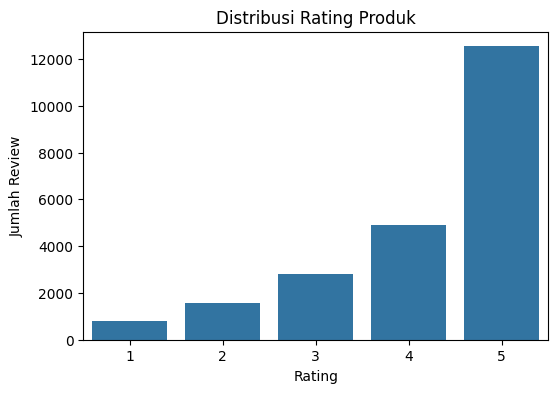

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Rating', data=df)

plt.title('Distribusi Rating Produk')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

plt.show()

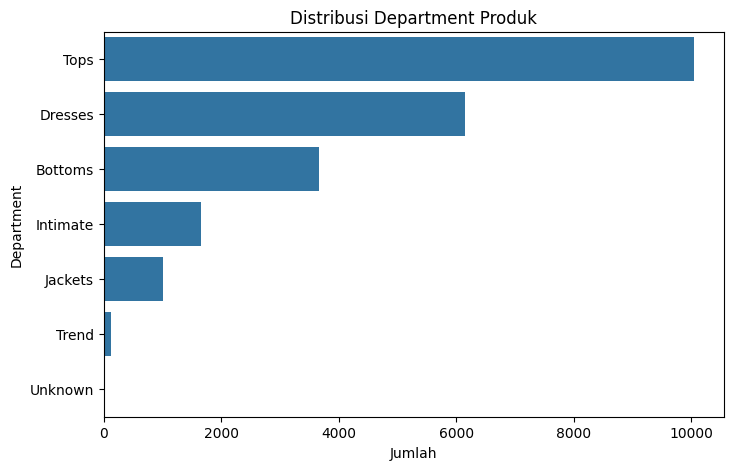

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y='Department Name', data=df,
              order=df['Department Name'].value_counts().index)

plt.title('Distribusi Department Produk')
plt.xlabel('Jumlah')
plt.ylabel('Department')

plt.show()

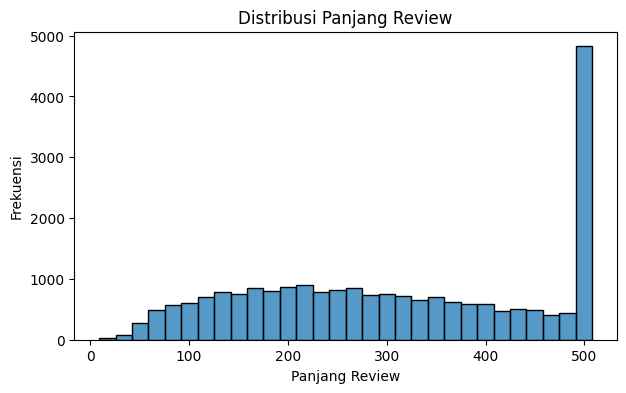

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['review_length'], bins=30)

plt.title('Distribusi Panjang Review')
plt.xlabel('Panjang Review')
plt.ylabel('Frekuensi')

plt.show()

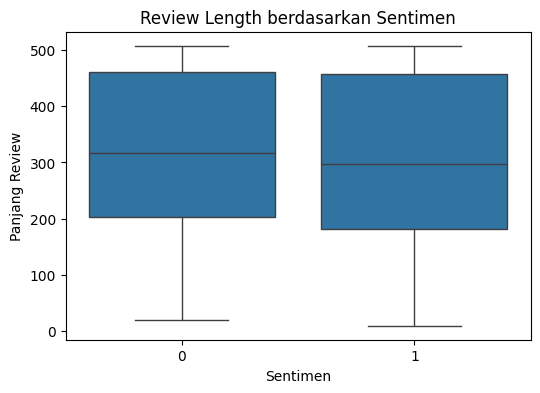

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Recommended IND', y='review_length', data=df)

plt.title('Review Length berdasarkan Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Panjang Review')

plt.show()

## Kesimpulan Sementara

Berdasarkan hasil EDA, dataset didominasi oleh review positif dengan rating tinggi. Selain itu, ditemukan bahwa kategori produk tertentu memiliki jumlah review lebih banyak dan review negatif cenderung memiliki teks yang lebih panjang. Hasil ini menjadi dasar untuk tahap preprocessing dan klasifikasi menggunakan algoritma SVM.

## Feature Selection

Pada tahap ini dilakukan pemilihan fitur yang relevan untuk proses analisis sentimen. Berdasarkan hasil Exploratory Data Analysis (EDA), fitur yang digunakan adalah:

- Review Text sebagai data teks utama
- Recommended IND sebagai label sentimen

Kolom lainnya digunakan pada tahap eksplorasi data untuk memahami karakteristik dataset.

In [ ]:
df_selected = df[['Review Text', 'Recommended IND']]

df_selected.head()

,Review Text,Recommended IND
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1
4,This shirt is very flattering to all due to th...,1


In [ ]:
df_selected.columns = ['review', 'label']

df_selected.head()

,review,label
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1
4,This shirt is very flattering to all due to th...,1


In [ ]:
df_selected['label'].value_counts()

,count
label,
1,18539
0,4101


Berdasarkan distribusi label, dataset didominasi oleh label positif. Hal ini menunjukkan bahwa sebagian besar pelanggan memberikan rekomendasi terhadap produk yang dibeli.

In [ ]:
df_selected.shape

(22640, 2)

In [ ]:
df_selected.isnull().sum()

,0
review,0
label,0


In [ ]:
df_selected.to_csv("selected_sentiment_data.csv", index=False)

## Text Preprocessing

Tahap text preprocessing dilakukan untuk membersihkan data teks agar lebih terstruktur dan siap digunakan pada proses ekstraksi fitur serta klasifikasi sentimen.

In [ ]:
df_preprocessed = df_selected.copy()

df_preprocessed.head()

,review,label
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1
4,This shirt is very flattering to all due to th...,1


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

# mempertahankan kata negasi
negation_words = {'not', 'no', 'never', "n't"}

stop_words = stop_words - negation_words

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    text = ' '.join(
        [word for word in text.split()
         if word not in stop_words]
    )

    return text

In [ ]:
df_preprocessed['clean_review'] = df_preprocessed['review'].apply(clean_text)

In [ ]:
df_preprocessed[['review', 'clean_review']].head(10)

,review,clean_review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...
2,I had such high hopes for this dress and reall...,high hopes dress really wanted work initially ...
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...
5,"I love tracy reese dresses, but this one is no...",love tracy reese dresses one not petite feet t...
6,I aded this in my basket at hte last mintue to...,aded basket hte last mintue see would look lik...
7,"I ordered this in carbon for store pick up, an...",ordered carbon store pick ton stuff always try...
8,I love this dress. i usually get an xs but it ...,love dress usually get xs runs little snug bus...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",im lbs ordered petite make sure length wasnt l...


In [ ]:
(df_preprocessed['clean_review'] == '').sum()

np.int64(0)

In [ ]:
df_preprocessed.to_csv(
    "preprocessed_sentiment_data.csv",
    index=False
)

## Hasil Preprocessing

Hasil preprocessing menunjukkan bahwa teks ulasan telah berhasil dibersihkan dari karakter yang tidak relevan, dinormalisasi, serta dikurangi kata-kata yang tidak memiliki kontribusi signifikan terhadap analisis sentimen.

## Feature Extraction menggunakan TF-IDF

Pada tahap ini, data teks diubah menjadi representasi numerik menggunakan metode TF-IDF (Term Frequency–Inverse Document Frequency). Metode ini digunakan untuk mengukur tingkat kepentingan suatu kata dalam dokumen terhadap keseluruhan corpus.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [ ]:
X = tfidf.fit_transform(df_preprocessed['clean_review'])

y = df_preprocessed['label']

In [ ]:
X.shape

(22640, 5000)

In [ ]:
tfidf.get_feature_names_out()[:20]

array(['able', 'able get', 'able try', 'able wear', 'absolute',
       'absolutely', 'absolutely adore', 'absolutely beautiful',
       'absolutely gorgeous', 'absolutely love', 'absolutely loved',
       'absolutely perfect', 'absolutely stunning', 'accent', 'accents',
       'accentuate', 'accentuated', 'accentuates', 'accessories',
       'accommodate'], dtype=object)

In [ ]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 716957 stored elements and shape (22640, 5000)>
  Coords	Values
  (0, 5)	0.384342318495126
  (0, 4826)	0.47420998180714313
  (0, 3748)	0.5487001468441198
  (0, 3641)	0.5038303807788999
  (0, 668)	0.26923776040089603
  (1, 2406)	0.13228363319520692
  (1, 1021)	0.07248679368182336
  (1, 3995)	0.22619646821622932
  (1, 3235)	0.10649614004897845
  (1, 1783)	0.21214635117104766
  (1, 1376)	0.1321520857412307
  (1, 4076)	0.11029742608377405
  (1, 1920)	0.07895391386521303
  (1, 1628)	0.14455316281677666
  (1, 233)	0.3828382422218104
  (1, 2721)	0.15641995197687283
  (1, 4876)	0.16635137562814284
  (1, 2953)	0.0899354885865579
  (1, 2923)	0.1152707213173544
  (1, 3113)	0.32746845654419837
  (1, 378)	0.09798438248282669
  (1, 2169)	0.10175918187391501
  (1, 1845)	0.15581794294976586
  (1, 2271)	0.09152064291131567
  (1, 2070)	0.15626835822687835
  :	:
  (22638, 2869)	0.1970935176851585
  (22638, 2009)	0.15280360284536776
  (22638, 4

## Hasil Feature Extraction

Hasil TF-IDF menunjukkan bahwa data teks berhasil direpresentasikan ke dalam bentuk numerik. Representasi ini akan digunakan sebagai input pada proses klasifikasi menggunakan algoritma Support Vector Machine (SVM).

## Train-Test Split

Pada tahap ini, data hasil representasi TF-IDF dibagi menjadi data training dan data testing.

Training data digunakan untuk melatih model Support Vector Machine (SVM), sedangkan testing data digunakan untuk mengevaluasi performa model terhadap data yang belum pernah dilihat sebelumnya.

Penelitian ini menggunakan rasio pembagian data sebesar 80:20 dengan parameter stratify untuk menjaga distribusi label sentimen tetap seimbang pada data training dan testing.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    df_preprocessed.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
print("Jumlah data training :", X_train.shape)
print("Jumlah data testing  :", X_test.shape)

Jumlah data training : (18112, 5000)
Jumlah data testing  : (4528, 5000)


In [ ]:
print("Distribusi Label Training:")
print(y_train.value_counts(normalize=True))

Distribusi Label Training:
label
1    0.818849
0    0.181151
Name: proportion, dtype: float64


In [ ]:
print("\nDistribusi Label Testing:")
print(y_test.value_counts(normalize=True))


Distribusi Label Testing:
label
1    0.818905
0    0.181095
Name: proportion, dtype: float64


In [ ]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (18112, 5000)
X_test  : (4528, 5000)
y_train : (18112,)
y_test  : (4528,)


## Training Model SVM

Pada tahap ini dilakukan pelatihan model klasifikasi sentimen menggunakan algoritma Support Vector Machine (SVM). Model dilatih menggunakan data hasil representasi TF-IDF yang telah dibagi menjadi data training dan data testing.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [ ]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [ ]:
train_predictions = svm_model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_predictions)

print("Training Accuracy :", train_accuracy)

Training Accuracy : 0.960523409893993


## Prediction pada Data Testing

Model yang telah dilatih selanjutnya digunakan untuk memprediksi label sentimen pada data testing.

In [ ]:
y_pred = svm_model.predict(X_test)

In [ ]:
prediction_results = pd.DataFrame({
    'Review': df_preprocessed.loc[test_idx, 'review'],
    'Actual Label': y_test.values,
    'Predicted Label': y_pred
})

prediction_results.head(10)

,Review,Actual Label,Predicted Label
9248,"I like this sweater, but it was like others i ...",1,1
13232,"It slips on easily, is soft & flattering. it w...",1,1
17573,These pants pair well with anything - dress up...,1,1
19850,First off: kudos to the other reviewers for se...,1,0
15017,Great jacket! warm as a coat yet thin enough t...,1,1
6088,I like the way this vest looks: it's flatterin...,1,1
22250,This dress is incredible! let me say that when...,1,1
5778,I tried this dress on in the store in the mang...,1,1
7112,I was a little hesitant when i ordered this dr...,1,1
4011,I ordered this quite nice cardigan. i received...,1,1


## Evaluation Metrics

Tahap evaluation metrics dilakukan untuk mengukur performa model Support Vector Machine (SVM) dalam melakukan klasifikasi sentimen pada data ulasan produk e-commerce.

Evaluasi model tidak hanya dilihat dari nilai accuracy, tetapi juga menggunakan precision, recall, dan F1-score agar performa model pada masing-masing kelas dapat dianalisis secara lebih detail.

Karena dataset memiliki distribusi label yang tidak seimbang, penggunaan beberapa metrik evaluasi menjadi penting agar hasil klasifikasi tidak bias terhadap kelas mayoritas.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))

Accuracy  : 0.8852
Precision : 0.9188
Recall    : 0.9431
F1-Score  : 0.9308


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.62      0.66       820
           1       0.92      0.94      0.93      3708

    accuracy                           0.89      4528
   macro avg       0.81      0.78      0.80      4528
weighted avg       0.88      0.89      0.88      4528



## Confusion Matrix

Confusion matrix digunakan untuk melihat detail hasil prediksi model pada masing-masing kelas.

Melalui confusion matrix, dapat diketahui:
- jumlah prediksi benar
- jumlah prediksi salah
- kesalahan klasifikasi antar kelas

Analisis confusion matrix penting untuk memahami perilaku model secara lebih mendalam.

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[ 511,  309],
       [ 211, 3497]])

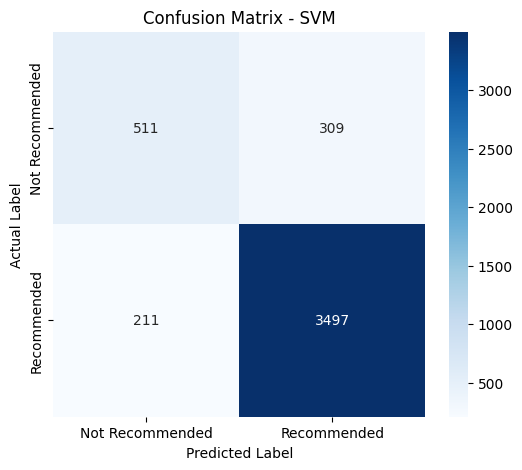

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Recommended', 'Recommended'],
    yticklabels=['Not Recommended', 'Recommended']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - SVM")

plt.show()

## Cross Validation

Tahap cross validation dilakukan untuk mengukur stabilitas performa model Support Vector Machine (SVM) pada beberapa pembagian data yang berbeda.

Metode yang digunakan adalah K-Fold Cross Validation dengan 5 fold menggunakan metrik accuracy.

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cv_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

cv_scores

array([0.88793817, 0.88904223, 0.88956378, 0.89591386, 0.89287686])

In [ ]:
print("Cross Validation Accuracy Scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Accuracy Scores:
[0.88793817 0.88904223 0.88956378 0.89591386 0.89287686]

Mean Accuracy:
0.891066980651409

Standard Deviation:
0.0029297299472601803


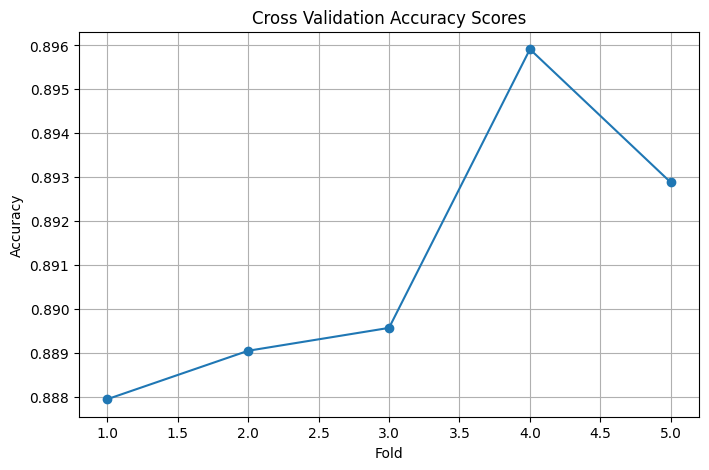

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker='o'
)

plt.title('Cross Validation Accuracy Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')

plt.grid(True)

plt.show()

## Hasil Cross Validation

Hasil cross validation menunjukkan bahwa model SVM memiliki performa yang relatif stabil pada setiap fold. Nilai accuracy antar fold tidak menunjukkan perbedaan yang terlalu jauh sehingga model dinilai mampu melakukan generalisasi data dengan cukup baik.

## Hyperparameter Tuning

Pada tahap ini dilakukan proses hyperparameter tuning untuk meningkatkan performa model Support Vector Machine (SVM). Tuning dilakukan dengan mencari kombinasi parameter terbaik menggunakan metode Grid Search dan Cross Validation.

Parameter yang diuji meliputi:
- Nilai parameter C
- Jenis loss function
- Jumlah iterasi model

Proses tuning bertujuan untuk memperoleh model dengan performa klasifikasi yang lebih optimal dibandingkan baseline model sebelumnya.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [1000, 3000, 5000]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=LinearSVC(),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearSVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'loss': ['hinge', 'squared_hinge'],
                         'max_iter': [1000, 3000, 5000]},
             scoring='f1_weighted')

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 1, 'loss': 'hinge', 'max_iter': 1000}

Best Cross Validation Score:
0.8911722638796871


In [ ]:
best_svm = grid_search.best_estimator_

In [ ]:
y_pred_tuning = best_svm.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy_tuning = accuracy_score(y_test, y_pred_tuning)

print("Accuracy After Tuning:", accuracy_tuning)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuning))

Accuracy After Tuning: 0.8933303886925795

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.61      0.67       820
           1       0.92      0.96      0.94      3708

    accuracy                           0.89      4528
   macro avg       0.84      0.78      0.80      4528
weighted avg       0.89      0.89      0.89      4528



In [ ]:
comparison = {
    'Model': ['Baseline SVM', 'Tuned SVM'],
    'Accuracy': [accuracy, accuracy_tuning]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy
0,Baseline SVM,0.885159
1,Tuned SVM,0.893330


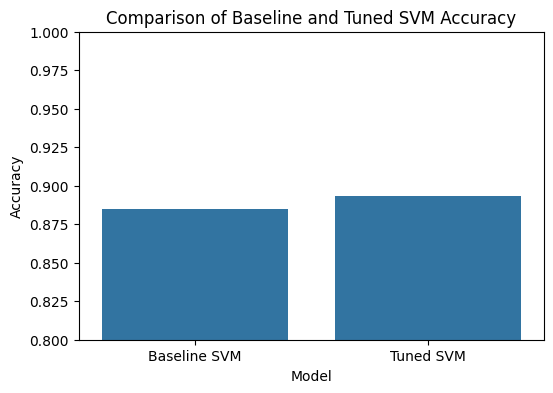

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Accuracy'
)

plt.title('Comparison of Baseline and Tuned SVM Accuracy')
plt.ylim(0.8, 1.0)

plt.show()

In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results[
    ['params', 'mean_test_score', 'rank_test_score']
].sort_values(
    by='rank_test_score'
).head(10)

,params,mean_test_score,rank_test_score
14,"{'C': 1, 'loss': 'hinge', 'max_iter': 5000}",0.891172,1
12,"{'C': 1, 'loss': 'hinge', 'max_iter': 1000}",0.891172,1
13,"{'C': 1, 'loss': 'hinge', 'max_iter': 3000}",0.891172,1
15,"{'C': 1, 'loss': 'squared_hinge', 'max_iter': ...",0.887759,4
17,"{'C': 1, 'loss': 'squared_hinge', 'max_iter': ...",0.887759,4
16,"{'C': 1, 'loss': 'squared_hinge', 'max_iter': ...",0.887759,4
11,"{'C': 0.1, 'loss': 'squared_hinge', 'max_iter'...",0.883801,7
9,"{'C': 0.1, 'loss': 'squared_hinge', 'max_iter'...",0.883801,7
10,"{'C': 0.1, 'loss': 'squared_hinge', 'max_iter'...",0.883801,7
18,"{'C': 10, 'loss': 'hinge', 'max_iter': 1000}",0.871174,10


## Handling Imbalanced Dataset

Pada tahap ini dilakukan penanganan terhadap ketidakseimbangan distribusi label sentimen pada dataset. Proses handling imbalance dilakukan menggunakan metode SMOTE (Synthetic Minority Oversampling Technique) untuk meningkatkan jumlah data pada kelas minoritas sehingga distribusi data menjadi lebih seimbang.

Penanganan imbalance dilakukan setelah proses train-test split dan sebelum training model dilakukan kembali.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
print("Distribusi label sebelum SMOTE:")
print(Counter(y_train))

Distribusi label sebelum SMOTE:
Counter({1: 14831, 0: 3281})


In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
print("Distribusi label setelah SMOTE:")
print(Counter(y_train_smote))

Distribusi label setelah SMOTE:
Counter({1: 14831, 0: 14831})


In [ ]:
before_smote = pd.DataFrame({
    'Label': list(Counter(y_train).keys()),
    'Jumlah': list(Counter(y_train).values()),
    'Kondisi': 'Sebelum SMOTE'
})

after_smote = pd.DataFrame({
    'Label': list(Counter(y_train_smote).keys()),
    'Jumlah': list(Counter(y_train_smote).values()),
    'Kondisi': 'Sesudah SMOTE'
})

distribution_df = pd.concat(
    [before_smote, after_smote],
    ignore_index=True
)

distribution_df

,Label,Jumlah,Kondisi
0,1,14831,Sebelum SMOTE
1,0,3281,Sebelum SMOTE
2,1,14831,Sesudah SMOTE
3,0,14831,Sesudah SMOTE


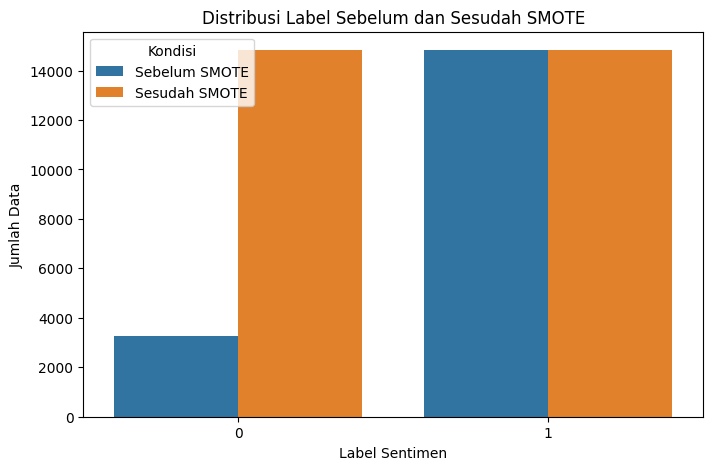

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=distribution_df,
    x='Label',
    y='Jumlah',
    hue='Kondisi'
)

plt.title('Distribusi Label Sebelum dan Sesudah SMOTE')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah Data')

plt.show()

In [ ]:
svm_smote = LinearSVC(
    C=1,
    loss='hinge',
    max_iter=5000
)

svm_smote.fit(
    X_train_smote,
    y_train_smote
)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=1, loss='hinge', max_iter=5000)

In [ ]:
y_pred_smote = svm_smote.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.62      0.79      0.69       820
           1       0.95      0.89      0.92      3708

    accuracy                           0.87      4528
   macro avg       0.78      0.84      0.81      4528
weighted avg       0.89      0.87      0.88      4528



In [ ]:
accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)

print("Accuracy After SMOTE:", accuracy_smote)

Accuracy After SMOTE: 0.8736749116607774


In [ ]:
comparison_all = pd.DataFrame({
    'Model': [
        'Baseline SVM',
        'Tuned SVM',
        'SVM + SMOTE'
    ],
    'Accuracy': [
        accuracy,
        accuracy_tuning,
        accuracy_smote
    ]
})

comparison_all

,Model,Accuracy
0,Baseline SVM,0.885159
1,Tuned SVM,0.893330
2,SVM + SMOTE,0.873675


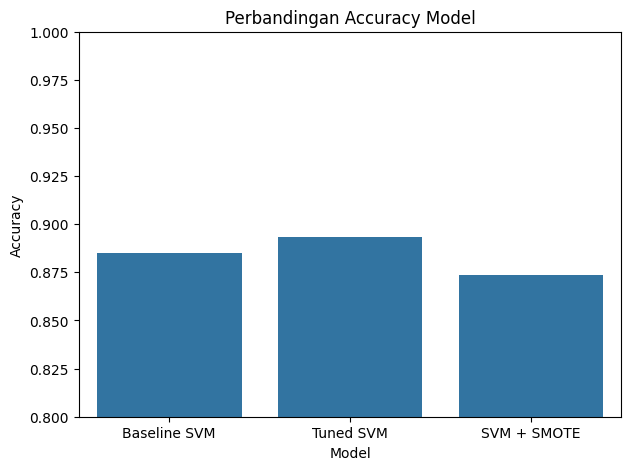

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison_all,
    x='Model',
    y='Accuracy'
)

plt.title('Perbandingan Accuracy Model')
plt.ylim(0.8, 1.0)

plt.show()

## Dimensionality Reduction Menggunakan Truncated SVD

Tahap dimensionality reduction dilakukan untuk mengurangi jumlah fitur hasil TF-IDF yang memiliki dimensi tinggi. Pada penelitian ini digunakan metode Truncated Singular Value Decomposition (Truncated SVD) karena metode ini lebih sesuai untuk data sparse matrix seperti hasil representasi TF-IDF.

Hasil reduksi dimensi selanjutnya digunakan sebagai input pada proses klasifikasi menggunakan algoritma Support Vector Machine (SVM).

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
svd = TruncatedSVD(
    n_components=300,
    random_state=42
)

X_train_svd = svd.fit_transform(X_train_resampled)
X_test_svd = svd.transform(X_test)

In [ ]:
print(X_train_resampled.shape)
print(X_train_svd.shape)

(29662, 5000)
(29662, 300)


In [ ]:
explained_variance = svd.explained_variance_ratio_.sum()

print("Total Explained Variance:", explained_variance)

Total Explained Variance: 0.3930429022078116


In [ ]:
svd_svm_model = LinearSVC(
    C=1,
    loss='hinge',
    max_iter=5000,
    random_state=42
)

svd_svm_model.fit(X_train_svd, y_train_resampled)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=1, loss='hinge', max_iter=5000, random_state=42)

In [ ]:
y_pred_svd = svd_svm_model.predict(X_test_svd)

In [ ]:
accuracy_svd = accuracy_score(y_test, y_pred_svd)

print("Accuracy After Dimensionality Reduction:", accuracy_svd)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svd))

Accuracy After Dimensionality Reduction: 0.859982332155477

Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.83      0.68       820
           1       0.96      0.87      0.91      3708

    accuracy                           0.86      4528
   macro avg       0.77      0.85      0.80      4528
weighted avg       0.89      0.86      0.87      4528



In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'Baseline SVM',
        'Tuned SVM',
        'SMOTE + Tuned SVM',
        'SVD + SMOTE + Tuned SVM'
    ],
    'Accuracy': [
        accuracy,
        accuracy_tuning,
        accuracy_smote,
        accuracy_svd
    ]
})

comparison_df

,Model,Accuracy
0,Baseline SVM,0.885159
1,Tuned SVM,0.893330
2,SMOTE + Tuned SVM,0.873675
3,SVD + SMOTE + Tuned SVM,0.859982


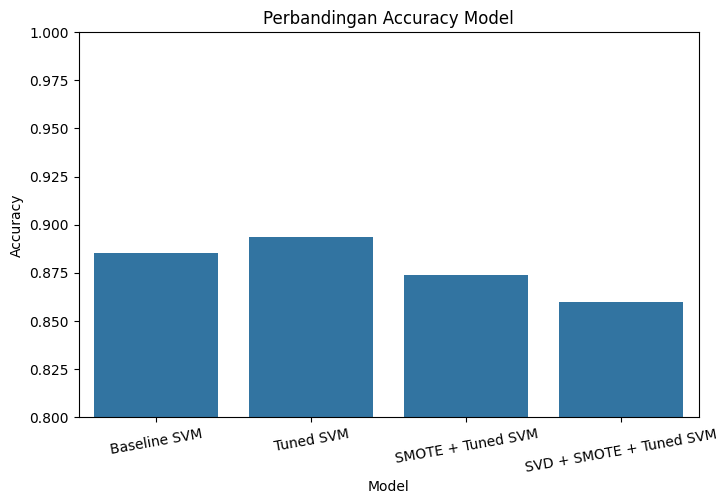

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Accuracy'
)

plt.title('Perbandingan Accuracy Model')
plt.ylabel('Accuracy')
plt.xlabel('Model')

plt.ylim(0.80, 1.00)

plt.xticks(rotation=10)

plt.show()

## Analisis Kata Dominan Sentimen (Feature Importance)

Tahap ini dilakukan untuk mengetahui kata-kata yang paling berpengaruh terhadap hasil klasifikasi sentimen pada model Support Vector Machine (SVM). Analisis dilakukan menggunakan bobot koefisien dari model LinearSVC terhadap fitur TF-IDF unigram dan bigram.

In [ ]:
feature_names = tfidf.get_feature_names_out()

In [ ]:
coef = best_svm.coef_[0]

In [ ]:
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef
})

feature_importance.head()

,feature,coefficient
0,able,0.889846
1,able get,0.072682
2,able try,0.246042
3,able wear,-0.204262
4,absolute,-0.024378


In [ ]:
top_positive = feature_importance.sort_values(
    by='coefficient',
    ascending=False
).head(15)

top_positive

,feature,coefficient
2406,love,3.037522
3077,perfect,2.820413
2271,little,2.582257
4525,unique,2.414871
4119,stunning,2.393904
1707,great,2.359781
1628,glad,2.293953
3952,soft,2.215064
668,comfortable,2.215026
710,compliments,2.076527


In [ ]:
top_negative = feature_importance.sort_values(
    by='coefficient',
    ascending=True
).head(15)

top_negative

,feature,coefficient
4626,wanted love,-4.650430
959,disappointed,-4.104909
2808,not flattering,-3.426358
3468,returning,-3.127881
1651,going back,-3.041770
4519,unflattering,-3.027645
192,awful,-3.006663
3466,returned,-2.977584
2842,not recommend,-2.840470
550,cheap,-2.781110


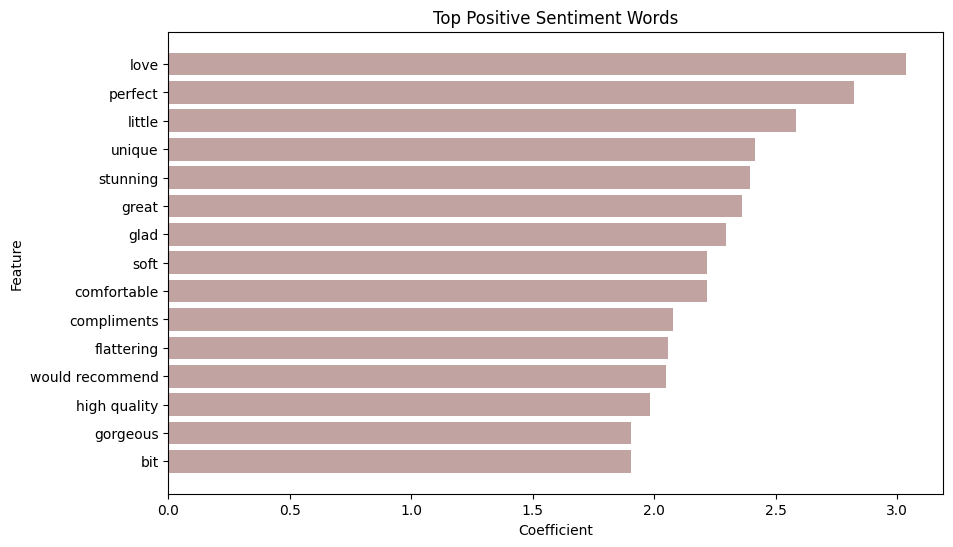

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top_positive['feature'],
    top_positive['coefficient'],
    color='#c1a3a1'
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top Positive Sentiment Words')

plt.gca().invert_yaxis()

plt.show()

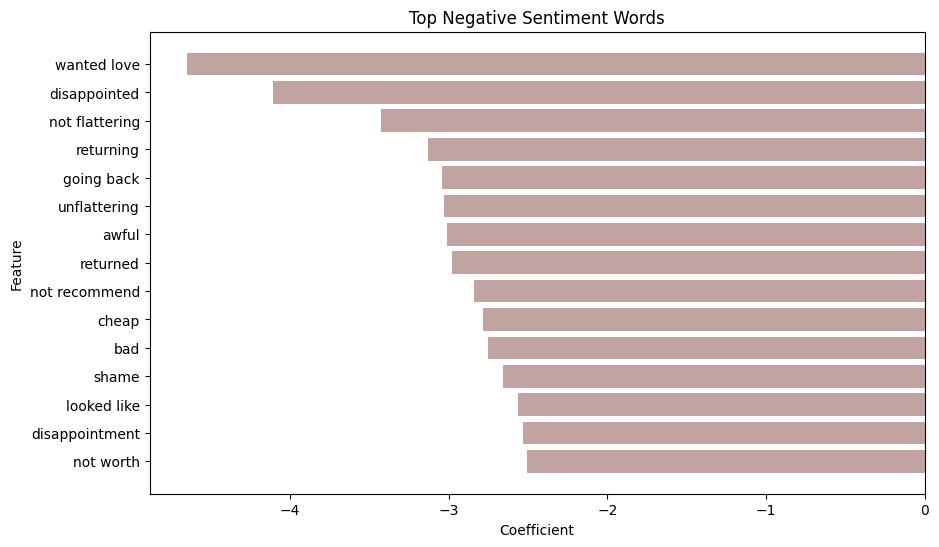

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top_negative['feature'],
    top_negative['coefficient'],
    color='#c1a3a1'
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top Negative Sentiment Words')

plt.gca().invert_yaxis()

plt.show()